In [1]:
import pandas as pd

df = pd.read_csv("retail_sales_india.csv")
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,IN-2024-103402,06-12-2024,12-12-2024,Standard Class,CU-1329,Isha Pillai,Consumer,India,Thiruvananthapuram,Kerala,South,OFF-STO-128,Office Supplies,Storage,Storage model 128,3514.15,2,0.15,737.09
1,IN-2024-103176,18-10-2024,21-10-2024,Second Class,CU-1354,Ashok Verma,Corporate,India,Kochi,Kerala,South,FUR-FUR-129,Furniture,Furnishings,Furnishings model 129,4043.37,3,0.20,575.52
2,IN-2025-103528,03-01-2025,03-01-2025,Same Day,CU-1146,Aditya Pillai,Consumer,India,Patna,Bihar,East,TEC-PHO-129,Technology,Phones,Phones model 129,27623.95,2,0.05,7971.88
3,IN-2022-100058,29-01-2022,04-02-2022,Standard Class,CU-1358,Ashok Verma,Consumer,India,Salem,Tamil Nadu,South,OFF-ART-127,Office Supplies,Art,Art model 127,769.25,3,0.05,298.13
4,IN-2024-103124,09-10-2024,10-10-2024,First Class,CU-1131,Vikram Iyer,Home Office,India,Thiruvananthapuram,Kerala,South,FUR-BOO-123,Furniture,Bookcases,Bookcases model 123,24493.35,4,0.05,4478.90


In [2]:
df.shape                 # how many rows and columns

(5035, 19)

In [3]:
df.info()                # column names, types, non-empty counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5035 entries, 0 to 5034
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5035 non-null   object 
 1   Order Date     5035 non-null   object 
 2   Ship Date      5035 non-null   object 
 3   Ship Mode      5035 non-null   object 
 4   Customer ID    5035 non-null   object 
 5   Customer Name  5035 non-null   object 
 6   Segment        4995 non-null   object 
 7   Country        5035 non-null   object 
 8   City           5035 non-null   object 
 9   State          5035 non-null   object 
 10  Region         5035 non-null   object 
 11  Product ID     5035 non-null   object 
 12  Category       5035 non-null   object 
 13  Sub-Category   5035 non-null   object 
 14  Product Name   5035 non-null   object 
 15  Sales          5035 non-null   object 
 16  Quantity       5035 non-null   int64  
 17  Discount       4955 non-null   float64
 18  Profit  

In [4]:
df.describe()            # min, max, average of number columns

,Quantity,Discount,Profit
count,5035.000000,4955.000000,5035.000000
mean,2.841509,0.115600,3415.901241
std,1.824736,0.111305,9795.431765
min,1.000000,0.000000,-15208.960000
25%,1.000000,0.000000,167.795000
50%,2.000000,0.100000,531.700000
75%,4.000000,0.200000,2029.620000
max,8.000000,0.550000,124595.530000


In [5]:
df.isnull().sum()        # missing values per column

,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,40
Country,0
City,0
State,0


In [6]:
df.duplicated().sum()    # number of repeated rows

np.int64(35)

In [7]:
df["Region"].value_counts()   # how many orders per region name

,count
Region,
West,1431
South,1430
North,1172
East,899
west,22
south,18
SOUTH,16
NORTH,14
north,10


## Day 1 Data Inspection Notes

1. **Size:** 5035 rows and 19 columns
2. **Missing values:** Discount has 80 missing, and Segment has 40 missing.
3. **Duplicate rows:** 35
4. **Region problem:** the same region is written in different ways (for example West, west and WEST with an extra space), so there are more than 4 names instead of 4.
5. **Wrong data types:** Order Date, Ship Date and Sales are stored as text

**Plan for Day 2 (cleaning):** remove duplicates, convert dates, convert Sales to numbers, fix Region names, fill missing values.

In [8]:
import pandas as pd
df = pd.read_csv("retail_sales_india.csv")

In [9]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (5035, 19)
After: (5000, 19)


In [10]:
df["Sales"] = (df["Sales"].astype(str)
               .str.replace("₹", "", regex=False)
               .str.replace(",", "", regex=False)
               .astype(float))
df["Sales"].dtype

dtype('float64')

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d-%m-%Y")
df[["Order Date","Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [12]:
df["Region"].nunique()          # check before
df["Region"] = df["Region"].str.strip().str.title()
df["Region"].nunique()          # check after — should be 4
df["Region"].value_counts()

,count
Region,
South,1454
West,1449
North,1189
East,908


In [13]:
df["Customer Name"] = df["Customer Name"].str.strip().str.title()

In [14]:
df["Discount"] = df["Discount"].fillna(0)
df["Segment"] = df["Segment"].fillna("Unknown")

df.isnull().sum()   # everything should now be 0

,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


In [15]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Profit Margin %"] = (df["Profit"] / df["Sales"] * 100).round(2)
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Profit Margin %,Shipping Days
0,IN-2024-103402,2024-12-06,2024-12-12,Standard Class,CU-1329,Isha Pillai,Consumer,India,Thiruvananthapuram,Kerala,...,Storage,Storage model 128,3514.15,2,0.15,737.09,2024,2024-12,20.97,6
1,IN-2024-103176,2024-10-18,2024-10-21,Second Class,CU-1354,Ashok Verma,Corporate,India,Kochi,Kerala,...,Furnishings,Furnishings model 129,4043.37,3,0.20,575.52,2024,2024-10,14.23,3
2,IN-2025-103528,2025-01-03,2025-01-03,Same Day,CU-1146,Aditya Pillai,Consumer,India,Patna,Bihar,...,Phones,Phones model 129,27623.95,2,0.05,7971.88,2025,2025-01,28.86,0
3,IN-2022-100058,2022-01-29,2022-02-04,Standard Class,CU-1358,Ashok Verma,Consumer,India,Salem,Tamil Nadu,...,Art,Art model 127,769.25,3,0.05,298.13,2022,2022-01,38.76,6
4,IN-2024-103124,2024-10-09,2024-10-10,First Class,CU-1131,Vikram Iyer,Home Office,India,Thiruvananthapuram,Kerala,...,Bookcases,Bookcases model 123,24493.35,4,0.05,4478.90,2024,2024-10,18.29,1


In [16]:
df.info()
df.isnull().sum().sum()   # should be 0
df.duplicated().sum()     # should be 0

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 5034
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order ID         5000 non-null   object        
 1   Order Date       5000 non-null   datetime64[ns]
 2   Ship Date        5000 non-null   datetime64[ns]
 3   Ship Mode        5000 non-null   object        
 4   Customer ID      5000 non-null   object        
 5   Customer Name    5000 non-null   object        
 6   Segment          5000 non-null   object        
 7   Country          5000 non-null   object        
 8   City             5000 non-null   object        
 9   State            5000 non-null   object        
 10  Region           5000 non-null   object        
 11  Product ID       5000 non-null   object        
 12  Category         5000 non-null   object        
 13  Sub-Category     5000 non-null   object        
 14  Product Name     5000 non-null   object      

np.int64(0)

In [17]:
df.to_csv("retail_sales_clean.csv", index=False)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 5034
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order ID         5000 non-null   object        
 1   Order Date       5000 non-null   datetime64[ns]
 2   Ship Date        5000 non-null   datetime64[ns]
 3   Ship Mode        5000 non-null   object        
 4   Customer ID      5000 non-null   object        
 5   Customer Name    5000 non-null   object        
 6   Segment          5000 non-null   object        
 7   Country          5000 non-null   object        
 8   City             5000 non-null   object        
 9   State            5000 non-null   object        
 10  Region           5000 non-null   object        
 11  Product ID       5000 non-null   object        
 12  Category         5000 non-null   object        
 13  Sub-Category     5000 non-null   object        
 14  Product Name     5000 non-null   object      

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("retail_sales_clean.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.info()   # quick check, should show 5000 rows, correct types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order ID         5000 non-null   object        
 1   Order Date       5000 non-null   datetime64[ns]
 2   Ship Date        5000 non-null   datetime64[ns]
 3   Ship Mode        5000 non-null   object        
 4   Customer ID      5000 non-null   object        
 5   Customer Name    5000 non-null   object        
 6   Segment          5000 non-null   object        
 7   Country          5000 non-null   object        
 8   City             5000 non-null   object        
 9   State            5000 non-null   object        
 10  Region           5000 non-null   object        
 11  Product ID       5000 non-null   object        
 12  Category         5000 non-null   object        
 13  Sub-Category     5000 non-null   object        
 14  Product Name     5000 non-null   object 

In [20]:
cat = df.groupby("Category")[["Sales","Profit"]].sum().round(0)
cat["Margin %"] = (cat["Profit"] / cat["Sales"] * 100).round(1)
print(cat)

                      Sales      Profit  Margin %
Category                                         
Furniture        18052528.0   1019291.0       5.6
Office Supplies   3220987.0    991605.0      30.8
Technology       67712276.0  15083201.0      22.3


                   Sales      Profit  Margin %
Sub-Category                                  
Tables         7471034.0    -74337.0      -1.0
Labels          179908.0     78629.0      43.7
Art             308447.0    105054.0      34.1
Paper           321684.0    133446.0      41.5
Binders         493356.0    182253.0      36.9
Furnishings     967011.0    200432.0      20.7
Accessories    1109495.0    340180.0      30.7
Bookcases      5610055.0    363296.0       6.5
Storage        1917593.0    492223.0      25.7
Chairs         4004428.0    529901.0      13.2
Machines      21331458.0   1773450.0       8.3
Phones        13655456.0   2705631.0      19.8
Copiers       31615868.0  10263940.0      32.5


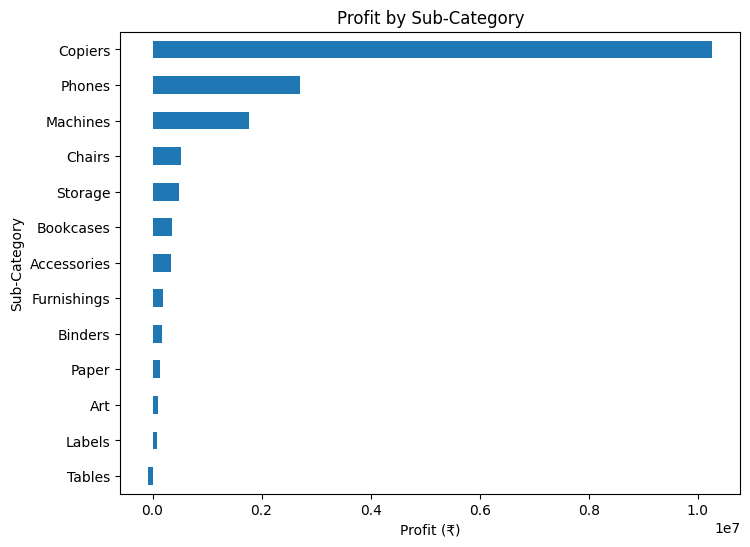

In [21]:
sub = df.groupby("Sub-Category")[["Sales","Profit"]].sum().round(0)
sub["Margin %"] = (sub["Profit"] / sub["Sales"] * 100).round(1)
print(sub.sort_values("Profit"))

sub["Profit"].sort_values().plot(kind="barh", figsize=(8,6), title="Profit by Sub-Category")
plt.xlabel("Profit (₹)")
plt.show()

             Sales     Profit  Margin %
Region                                 
East    14812569.0  2457333.0      16.6
North   22837051.0  4414282.0      19.3
South   25389773.0  4969093.0      19.6
West    25946398.0  5253389.0      20.2


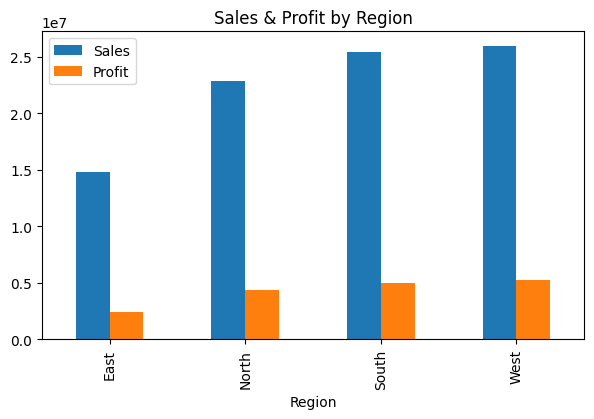

State
Odisha          741433.0
West Bengal     809130.0
Bihar           906771.0
Delhi           996033.0
Kerala         1111186.0
Name: Profit, dtype: float64


In [22]:
region = df.groupby("Region")[["Sales","Profit"]].sum().round(0)
region["Margin %"] = (region["Profit"] / region["Sales"] * 100).round(1)
print(region)

region[["Sales","Profit"]].plot(kind="bar", figsize=(7,4), title="Sales & Profit by Region")
plt.show()

print(df.groupby("State")["Profit"].sum().round(0).sort_values().head(5))   # worst 5 states

Discount Band
0%        7882402.0
1-10%     5884260.0
11-20%    3404242.0
21-30%     187186.0
30%+      -263994.0
Name: Profit, dtype: float64


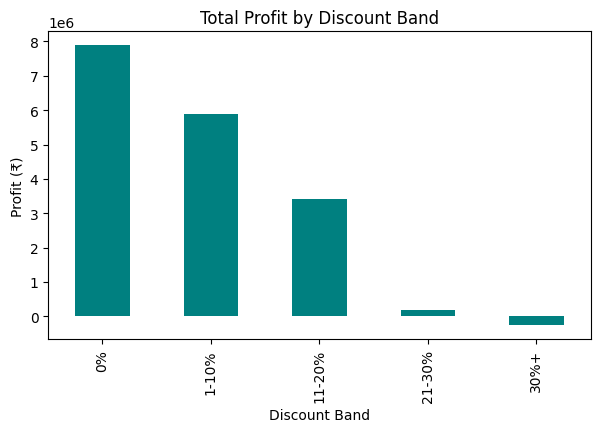

In [23]:
df["Discount Band"] = pd.cut(df["Discount"], [-0.01, 0, 0.1, 0.2, 0.3, 0.6],
                              labels=["0%","1-10%","11-20%","21-30%","30%+"])

band = df.groupby("Discount Band", observed=True)["Profit"].sum().round(0)
print(band)

band.plot(kind="bar", figsize=(7,4), title="Total Profit by Discount Band", color="teal")
plt.ylabel("Profit (₹)")
plt.show()

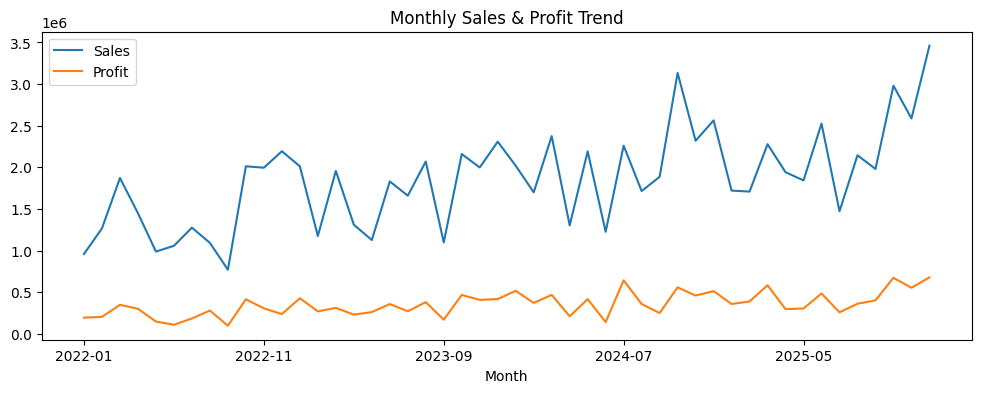

           Sales     Profit
Year                       
2022  16936558.0  2836590.0
2023  20710762.0  3984463.0
2024  24694713.0  4917825.0
2025  26643757.0  5355219.0


In [24]:
monthly = df.groupby("Month")[["Sales","Profit"]].sum().round(0)
monthly.plot(figsize=(12,4), title="Monthly Sales & Profit Trend")
plt.show()

yearly = df.groupby("Year")[["Sales","Profit"]].sum().round(0)
print(yearly)

In [25]:
print(df.groupby("Customer Name")["Sales"].sum().round(0).nlargest(10))

seg = df.groupby("Segment")[["Sales","Profit"]].sum().round(0)
seg["Margin %"] = (seg["Profit"] / seg["Sales"] * 100).round(1)
print(seg)

Customer Name
Kavya Iyer        1501808.0
Arjun Gupta       1247289.0
Aarav Patel       1099081.0
Neha Verma        1043849.0
Ashok Verma       1018255.0
Divya Kumar        966977.0
Ananya Singh       927219.0
Arjun Joshi        921088.0
Swathi Verma       915872.0
Lakshmi Pillai     885257.0
Name: Sales, dtype: float64
                  Sales     Profit  Margin %
Segment                                     
Consumer     47518681.0  9170078.0      19.3
Corporate    26577165.0  5165391.0      19.4
Home Office  14172448.0  2605810.0      18.4
Unknown        717497.0   152818.0      21.3


In [26]:
yearly = df.groupby("Year")[["Sales","Profit"]].sum()
(yearly["Profit"]/yearly["Sales"]*100).round(1)

,0
Year,
2022,16.7
2023,19.2
2024,19.9
2025,20.1


In [27]:
import pandas as pd
import sqlite3

df = pd.read_csv("retail_sales_clean.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

conn = sqlite3.connect("retail.db")
df.to_sql("orders", conn, if_exists="replace", index=False)

def q(sql):
    return pd.read_sql(sql, conn)

In [28]:
q("""
SELECT ROUND(SUM(Sales)) AS total_sales,
       ROUND(SUM(Profit)) AS total_profit,
       ROUND(SUM(Profit)*100.0/SUM(Sales), 1) AS margin_pct
FROM orders
""")

,total_sales,total_profit,margin_pct
0,88985791.0,17094097.0,19.2


In [29]:
q("""
SELECT Category, ROUND(SUM(Sales)) AS sales, ROUND(SUM(Profit)) AS profit
FROM orders
GROUP BY Category
ORDER BY profit DESC
""")

,Category,sales,profit
0,Technology,67712276.0,15083201.0
1,Furniture,18052528.0,1019291.0
2,Office Supplies,3220987.0,991605.0


In [30]:
q("""
SELECT "Sub-Category", ROUND(SUM(Profit)) AS profit
FROM orders
GROUP BY "Sub-Category"
HAVING SUM(Profit) < 0
""")

,Sub-Category,profit
0,Tables,-74337.0


In [31]:
q("""
SELECT COUNT(*) AS risky_orders
FROM orders
WHERE Discount > 0.3 AND Profit < 0
""")

,risky_orders
0,152


In [32]:
q("""
SELECT "Customer Name", ROUND(SUM(Sales)) AS sales
FROM orders
GROUP BY "Customer Name"
ORDER BY sales DESC
LIMIT 10
""")

,Customer Name,sales
0,Kavya Iyer,1501808.0
1,Arjun Gupta,1247289.0
2,Aarav Patel,1099081.0
3,Neha Verma,1043849.0
4,Ashok Verma,1018255.0
5,Divya Kumar,966977.0
6,Ananya Singh,927219.0
7,Arjun Joshi,921088.0
8,Swathi Verma,915872.0
9,Lakshmi Pillai,885257.0


In [33]:
q("""
SELECT * FROM (
    SELECT Segment, "Customer Name",
           ROUND(SUM(Sales)) AS sales,
           RANK() OVER (PARTITION BY Segment ORDER BY SUM(Sales) DESC) AS rnk
    FROM orders
    GROUP BY Segment, "Customer Name"
)
WHERE rnk <= 3
""")

,Segment,Customer Name,sales,rnk
0,Consumer,Kavya Kumar,739707.0,1
1,Consumer,Arjun Joshi,726735.0,2
2,Consumer,Nisha Kumar,706513.0,3
3,Corporate,Kavya Iyer,1183153.0,1
4,Corporate,Arjun Gupta,877132.0,2
5,Corporate,Aarav Patel,756247.0,3
6,Home Office,Pooja Verma,450638.0,1
7,Home Office,Ravi Shah,403572.0,2
8,Home Office,Ravi Reddy,403103.0,3
9,Unknown,Ashok Menon,235092.0,1


In [34]:
q("""
SELECT strftime('%Y', "Order Date") AS year,
       ROUND(SUM(Sales)) AS sales,
       ROUND(SUM(Profit)) AS profit
FROM orders
GROUP BY year
ORDER BY year
""")

,year,sales,profit
0,2022,16936558.0,2836590.0
1,2023,20710762.0,3984463.0
2,2024,24694713.0,4917825.0
3,2025,26643757.0,5355219.0


In [35]:
q("""
SELECT
    CASE
        WHEN Discount = 0 THEN '0%'
        WHEN Discount <= 0.1 THEN '1-10%'
        WHEN Discount <= 0.2 THEN '11-20%'
        WHEN Discount <= 0.3 THEN '21-30%'
        ELSE '30%+'
    END AS discount_band,
    ROUND(SUM(Profit)) AS profit
FROM orders
GROUP BY discount_band
""")

,discount_band,profit
0,0%,7882402.0
1,1-10%,5884260.0
2,11-20%,3404242.0
3,21-30%,187186.0
4,30%+,-263994.0


In [36]:
region_target = pd.DataFrame({
    "Region": ["East","West","North","South"],
    "Target_Margin": [20, 20, 20, 20]
})
region_target.to_sql("targets", conn, if_exists="replace", index=False)

q("""
SELECT o.Region,
       ROUND(SUM(o.Profit)*100.0/SUM(o.Sales), 1) AS actual_margin,
       t.Target_Margin
FROM orders o
JOIN targets t ON o.Region = t.Region
GROUP BY o.Region
""")

,Region,actual_margin,Target_Margin
0,East,16.6,20
1,North,19.3,20
2,South,19.6,20
3,West,20.2,20


-- Retail Sales Analysis: SQL Queries
-- Author: Ashok S

-- 1. Overall business summary: total sales, profit, and margin
SELECT ROUND(SUM(Sales)) AS total_sales,
       ROUND(SUM(Profit)) AS total_profit,
       ROUND(SUM(Profit)*100.0/SUM(Sales), 1) AS margin_pct
FROM orders;

-- 2. Sales and profit by category
SELECT Category, ROUND(SUM(Sales)) AS sales, ROUND(SUM(Profit)) AS profit
FROM orders
GROUP BY Category
ORDER BY profit DESC;

-- 3. Sub-categories that lose money overall
SELECT "Sub-Category", ROUND(SUM(Profit)) AS profit
FROM orders
GROUP BY "Sub-Category"
HAVING SUM(Profit) < 0;

-- 4. Top 10 customers by total sales
SELECT "Customer Name", ROUND(SUM(Sales)) AS sales
FROM orders
GROUP BY "Customer Name"
ORDER BY sales DESC
LIMIT 10;

-- 5. Top 3 customers within each segment (window function)
SELECT * FROM (
    SELECT Segment, "Customer Name",
           ROUND(SUM(Sales)) AS sales,
           RANK() OVER (PARTITION BY Segment ORDER BY SUM(Sales) DESC) AS rnk
    FROM orders
    GROUP BY Segment, "Customer Name"
)
WHERE rnk <= 3;

-- 6. Year-over-year sales and profit
SELECT strftime('%Y', "Order Date") AS year,
       ROUND(SUM(Sales)) AS sales,
       ROUND(SUM(Profit)) AS profit
FROM orders
GROUP BY year
ORDER BY year;

-- 7. Profit by discount band
SELECT
    CASE
        WHEN Discount = 0 THEN '0%'
        WHEN Discount <= 0.1 THEN '1-10%'
        WHEN Discount <= 0.2 THEN '11-20%'
        WHEN Discount <= 0.3 THEN '21-30%'
        ELSE '30%+'
    END AS discount_band,
    ROUND(SUM(Profit)) AS profit
FROM orders
GROUP BY discount_band;

-- 8. Region performance vs a 20% margin target (JOIN)
SELECT o.Region,
       ROUND(SUM(o.Profit)*100.0/SUM(o.Sales), 1) AS actual_margin,
       t.Target_Margin
FROM orders o
JOIN targets t ON o.Region = t.Region
GROUP BY o.Region;

In [37]:
queries = """-- paste the full block above here, exactly as written"""

with open("queries.sql", "w") as f:
    f.write(queries)